## Remote content and animal traveling direction

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt

In [3]:
from spyglass.shijiegu.changeOfMind_figures.figure4d import find_angle_animal
from spyglass.shijiegu.Analysis_SGU import ChangeofMind, Imu

/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an at

In [4]:
from spyglass.shijiegu.changeOfMind import nodes
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.shijiegu.helpers import interpolate_to_new_time

In [5]:
from spyglass.shijiegu.gyroscope import load_tracking_result, load_tracking_data_position

In [6]:
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.common.common_position import IntervalPositionInfo
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.ripple_add_replay import select_subset_helper, select_subset_helper_pd

In [124]:
from spyglass.shijiegu.changeOfMind_figures.traveling_direction import (
    return_traveling_directions_behavior, plot_traveling_directions_prep, plot_traveling_directions, return_traveling_directions)

### 1. Behavior only 

In [24]:
list_of_days_animals, encoding_set_animals, classifier_param_name_animals = {}, {}, {}

In [25]:
animal = "julio"
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

In [26]:
animal = "klein"
list_of_days_animals[animal] = ['20231101','20231102','20231103','20231104','20231105',#
                 '20231106','20231107','20231108']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

In [27]:
animal = "molly"
list_of_days_animals[animal] = ['20220416','20220417','20220418','20220419','20220420']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

In [102]:
backing_total_times = {}
forward_total_times = {}

for animal in ["julio", "klein", "molly"]:
    backing_total_times[animal], forward_total_times[animal] = return_traveling_directions_behavior(
        animal, list_of_days_animals[animal], imu_name = "big_acc_bias", n = 4)
    
output_path = f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/traveling_direction_behavior.pkl'
data= {"backing_total_times":backing_total_times, "forward_total_times": forward_total_times}
with open(output_path, 'wb') as file:
    pickle.dump(data, file)

[2026-05-10 18:06:34,632][WARNING]: Skipped checksum for file with hash: ed63b199-056f-daa7-f44f-152919f498eb, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_UX6B20HBXI.nwb


julio20230731_.nwb


[18:06:35][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-05-10 18:06:36,673][WARNING]: Skipped checksum for file with hash: e3110800-a607-4956-4875-d53387fc1050, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_36HZ4X4TXC.nwb
[2026-05-10 18:06:36,679][WARNING]: Skipped checksum for file with hash: e3110800-a607-4956-4875-d53387fc1050, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_36HZ4X4TXC.nwb
[2026-05-10 18:06:36,970][WARNING]: Skipped checksum for file with hash: 3a192129-a909-c408-8a47-7af36a33edf5, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_MXZMD96E2E.nwb
[18:06:37][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_po

julio20230801_.nwb


[18:06:49][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-05-10 18:06:51,009][WARNING]: Skipped checksum for file with hash: 75f4b377-3ea8-08e7-2313-c4da5b4b4b4c, and path: /stelmo/nwb/analysis/julio20230801/julio20230801_0FFZKC7R92.nwb
[2026-05-10 18:06:51,015][WARNING]: Skipped checksum for file with hash: 75f4b377-3ea8-08e7-2313-c4da5b4b4b4c, and path: /stelmo/nwb/analysis/julio20230801/julio20230801_0FFZKC7R92.nwb
[2026-05-10 18:06:51,170][WARNING]: Skipped checksum for file with hash: 5072e7a0-0f07-f07a-549d-71380b0b6f35, and path: /stelmo/nwb/analysis/julio20230801/julio20230801_ZXZ1H2V6JO.nwb
[18:06:51][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_po

...

[18:11:51][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-05-10 18:11:53,377][WARNING]: Skipped checksum for file with hash: 3607b374-fbb9-5525-1e1f-6e7af3faca49, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_ICI7K1NSNF.nwb
[2026-05-10 18:11:53,383][WARNING]: Skipped checksum for file with hash: 3607b374-fbb9-5525-1e1f-6e7af3faca49, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_ICI7K1NSNF.nwb
[2026-05-10 18:11:53,625][WARNING]: Skipped checksum for file with hash: 8622030b-cdf2-b41e-70d4-aa08baca589d, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_YQIBZ9GUKT.nwb
[18:11:54][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_po

molly20220419_.nwb


[18:12:05][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-05-10 18:12:07,178][WARNING]: Skipped checksum for file with hash: cf24106f-7f67-0999-a26a-923bafb75b10, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_I8NJO669C4.nwb
[2026-05-10 18:12:07,185][WARNING]: Skipped checksum for file with hash: cf24106f-7f67-0999-a26a-923bafb75b10, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_I8NJO669C4.nwb
[2026-05-10 18:12:08,246][WARNING]: Skipped checksum for file with hash: 6830800f-e479-2461-5db0-36ce0f47f67f, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_1GQW3M3ERM.nwb
[18:12:08][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_po

molly20220420_.nwb
No triggered decode found for  {'nwb_file_name': 'molly20220420_.nwb', 'epoch': 2, 'proportion': 0.1, 'parameter': 'params_both_max_segment_run_time_2_state'}


[18:12:19][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-05-10 18:12:20,821][WARNING]: Skipped checksum for file with hash: 1e10820c-698c-8a0a-688f-04b8550f3a6c, and path: /stelmo/nwb/analysis/molly20220420/molly20220420_8AYHP60RN8.nwb
[2026-05-10 18:12:20,828][WARNING]: Skipped checksum for file with hash: 1e10820c-698c-8a0a-688f-04b8550f3a6c, and path: /stelmo/nwb/analysis/molly20220420/molly20220420_8AYHP60RN8.nwb
[2026-05-10 18:12:21,465][WARNING]: Skipped checksum for file with hash: c9ecc4bb-5018-9a01-11b1-606777b87de4, and path: /stelmo/nwb/analysis/molly20220420/molly20220420_ZNWPCET91Q.nwb
[18:12:21][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_po

### Plot

In [110]:
output_path = f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/traveling_direction_behavior.pkl'

with open(output_path, 'rb') as file:
    loaded_data = pickle.load(file)

backing_total_times = loaded_data["backing_total_times"]
forward_total_times = loaded_data["forward_total_times"]

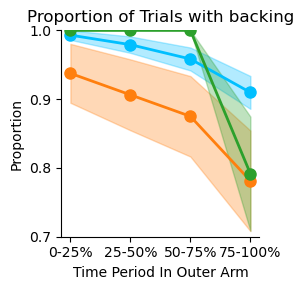

In [122]:
mean_proportions = {}
sem_proportions = {}
for animal in ["julio", "klein", "molly"]:
    mean_proportions[animal], sem_proportions[animal] = plot_traveling_directions_prep(backing_total_times[animal],
                                                                                       forward_total_times[animal],
                                                                                      n = 4)

fig, ax = plot_traveling_directions(mean_proportions, sem_proportions)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure4/traveling_direction_behavior"
plt.savefig(file_path + ".pdf",bbox_inches='tight')
plt.savefig(file_path + ".png")

### 2. Find for each remote or local extended content interval, the proportion of events that occured when rats are backing or forwarding.

In [156]:
backing_total_times

[1.7081942558288574,
 2.3914895057678223,
 1.4092659950256348,
 2.306075096130371,
 0.5978684425354004,
 1.4519717693328857,
 0.9822111129760742,
 1.6227855682373047,
 4.227805852890015,
 0.6405613422393799,
 1.0249378681182861,
 1.1530492305755615,
 2.9039382934570312,
 3.2455735206604004,
 1.2811553478240967,
 0.9822103977203369,
 1.3665525913238525,
 1.8363244533538818,
 1.1957294940948486,
 1.8790233135223389,
 4.22780442237854,
 3.5017964839935303,
 2.989358901977539,
 1.494680404663086]

array([0.        , 6.69057915, 0.        ,        nan, 4.68327542,
       0.        ,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan])

array([0.        , 0.        , 0.        , 0.86727445, 1.67260877,
       0.        , 1.01811106, 0.61622436, 0.47305862, 0.        ,
       0.        , 1.73453132, 0.34435993, 0.        , 0.78054547,
       0.        , 0.        , 0.54456608, 0.        , 1.06438275,
       0.        , 0.        , 0.        , 0.66903935])

In [162]:
directions_r = {}
directions_le= {}
forward_rate = {}
backing_rate = {}

for animal in ["julio", "klein", "molly"]:
    (directions_r[animal], forward_rate[animal], backing_rate[animal]
        ) = return_traveling_directions(
         animal, list_of_days_animals[animal], imu_name = "big_acc_bias",
                                         remote_flag = True)
    directions_le[animal] = return_traveling_directions(animal, list_of_days_animals[animal], imu_name = "big_acc_bias",
                                         remote_flag = False)

        
output_path = f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/traveling_direction_neural.pkl'
data= {"directions_r":directions_r, "directions_le": directions_le, "forward_rate": forward_rate, 
      "backing_rate": backing_rate}
with open(output_path, 'wb') as file:
    pickle.dump(data, file)

[2026-05-10 22:06:16,246][WARNING]: Reconnecting to MySQL server.


julio20230731_.nwb


[2026-05-10 22:06:16,552][WARNING]: Skipped checksum for file with hash: ed63b199-056f-daa7-f44f-152919f498eb, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_UX6B20HBXI.nwb
[2026-05-10 22:06:17,319][WARNING]: Skipped checksum for file with hash: 3a192129-a909-c408-8a47-7af36a33edf5, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_MXZMD96E2E.nwb
[2026-05-10 22:06:18,137][WARNING]: Skipped checksum for file with hash: 309e9a76-e05e-2c53-0671-f4116f549751, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_JS9EG0RK1D.nwb
[2026-05-10 22:06:18,633][WARNING]: Skipped checksum for file with hash: 5575c860-47d2-232b-c678-72361f3dbb56, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_6CU7OPDSQX.nwb
[2026-05-10 22:06:19,155][WARNING]: Skipped checksum for file with hash: 5bc1d382-4a0b-3898-714a-196cadc97822, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_L4EGAGNBH0.nwb
[2026-05-10 22:06:19,768][WARNING]: Skipped checksum for file with hash: 44

julio20230801_.nwb


[2026-05-10 22:06:20,474][WARNING]: Skipped checksum for file with hash: 5072e7a0-0f07-f07a-549d-71380b0b6f35, and path: /stelmo/nwb/analysis/julio20230801/julio20230801_ZXZ1H2V6JO.nwb
[2026-05-10 22:06:21,142][WARNING]: Skipped checksum for file with hash: a5753805-5352-7033-2f40-2de7c02997b2, and path: /stelmo/nwb/analysis/julio20230801/julio20230801_NNOESO121X.nwb
[2026-05-10 22:06:21,719][WARNING]: Skipped checksum for file with hash: 07e875c0-7a5b-e613-b545-e665e529fbd4, and path: /stelmo/nwb/analysis/julio20230802/julio20230802_KN1L1KIUYR.nwb


...

[2026-05-10 22:08:45,822][WARNING]: Skipped checksum for file with hash: 8622030b-cdf2-b41e-70d4-aa08baca589d, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_YQIBZ9GUKT.nwb
[2026-05-10 22:08:46,464][WARNING]: Skipped checksum for file with hash: 39f13569-f09b-63d0-f35a-c7a09901db4b, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_IPD2UYQ86E.nwb
[2026-05-10 22:08:47,408][WARNING]: Skipped checksum for file with hash: 03c650dc-3eb5-956a-7b2d-5b4f71076e00, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_IBWAMVV75E.nwb
[2026-05-10 22:08:48,017][WARNING]: Skipped checksum for file with hash: 093f7e5c-97a0-c213-979b-a67afcf22661, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_84VHWCJXRR.nwb
[2026-05-10 22:08:48,808][WARNING]: Skipped checksum for file with hash: ae3bbee0-5e37-4f29-d91d-14bad4946be3, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_I13PH3NV36.nwb


molly20220419_.nwb


[2026-05-10 22:08:49,579][WARNING]: Skipped checksum for file with hash: 6830800f-e479-2461-5db0-36ce0f47f67f, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_1GQW3M3ERM.nwb
[2026-05-10 22:08:50,183][WARNING]: Skipped checksum for file with hash: e1103743-17ee-5e9f-9341-b1b65471aa0d, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_LH2YG19D1L.nwb
[2026-05-10 22:08:50,957][WARNING]: Skipped checksum for file with hash: 484437d3-06c3-2039-cfcb-4cdb4b9afede, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_8LSUF8SQDP.nwb
[2026-05-10 22:08:51,498][WARNING]: Skipped checksum for file with hash: e2159c13-b55f-1971-8942-adf6a05e29bf, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_W11EPFZWMY.nwb


molly20220420_.nwb


[2026-05-10 22:08:52,219][WARNING]: Skipped checksum for file with hash: 254f0558-499e-a1c5-5bbc-e2eb178cd096, and path: /stelmo/nwb/analysis/molly20220420/molly20220420_WMQ808ATKK.nwb
[2026-05-10 22:08:52,854][WARNING]: Skipped checksum for file with hash: c9ecc4bb-5018-9a01-11b1-606777b87de4, and path: /stelmo/nwb/analysis/molly20220420/molly20220420_ZNWPCET91Q.nwb
[2026-05-10 22:08:53,417][WARNING]: Skipped checksum for file with hash: 44ba9b2a-a5de-2526-4d69-10b790586318, and path: /stelmo/nwb/analysis/molly20220420/molly20220420_5LHBM7ZBAH.nwb
[2026-05-10 22:08:54,212][WARNING]: Skipped checksum for file with hash: e43cb378-91b6-c4a4-3eae-a9435141bd41, and path: /stelmo/nwb/analysis/molly20220420/molly20220420_TUGDHD241P.nwb
[2026-05-10 22:08:54,892][WARNING]: Skipped checksum for file with hash: 53842d3e-76aa-6dd2-64d0-7675dccde388, and path: /stelmo/nwb/analysis/molly20220420/molly20220420_QMKRAV70LR.nwb


### Plot

In [163]:
output_path = f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/traveling_direction_neural.pkl'

with open(output_path, 'rb') as file:
    loaded_data = pickle.load(file)
directions_r = loaded_data["directions_r"]
directions_le = loaded_data["directions_le"]
forward_rate = loaded_data["forward_rate"]
backing_rate = loaded_data["backing_rate"]

In [140]:
from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm
color_by_rat = {"eliot": "C0","molly":"C2","lewis":"C4","julio":"C1","klein":"deepskyblue"}

def sd_err(arr):
    return np.std(arr)/np.sqrt(len(arr))

def plot_one_axis(data1, data2, animal_ind, ax, animal, draw_annotation = False, draw_text = True):
    std = [sd_err(data1), sd_err(data2)]
    mean = [np.mean(data1), np.mean(data2)]
    ax.bar([0 + animal_ind,
                0.3 + animal_ind],mean, yerr=std, width=0.25, hatch=['', '////'],color = color_by_rat[animal], alpha=0.8)
    if draw_text:
        ax.text(animal_ind - 0.15, mean[0]+std[0] + 0.1, len(data1), fontsize = 6)
        ax.text(animal_ind + 0.3 - 0.15, mean[1]+std[1] + 0.1, len(data2), fontsize = 6)
        
    table = np.array([[np.sum(data1 == 0), np.sum(data1 == 1)],[np.sum(data2 == 0), np.sum(data2 == 1)]])
    res = fisher_exact(table, alternative = "greater")
    p_value = res.pvalue
    if p_value < 0.05 and draw_annotation:
        starbars.draw_annotation([(animal_ind, animal_ind + 0.3, np.round(p_value, 4))], ax = ax)
    return ax, p_value

def draw_annotation(ijps,ax,height = 0.9):
    for ijp in ijps:
        x1, x2, p = ijp
        if p <= 0.001:
            label = "***"
        elif p <= 0.01:
            label = "**"
        elif p <= 0.05:
            label = "*"
        ax.text(np.mean([x1,x2]), height, label)

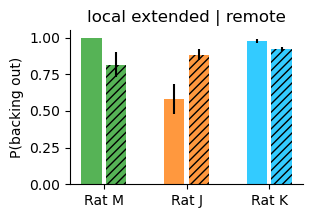

In [153]:
animal_ind = 0
animals = ["molly", "julio", "klein"]
draw_text = False
fig, ax = plt.subplots(1, 1, figsize=(3, 2))#sharey = True)

for animal in animals:
    data2 = np.array(directions_r[animal])
    data1 = np.array(directions_le[animal])
    data1[data1 > 0.5] = 1
    data1[data1 < -0.5] = 0

    data2[data2 > 0.5] = 1
    data2[data2 < -0.5] = 0
    plot_one_axis(data1, data2, animal_ind, ax, animal, draw_annotation = False, draw_text = False)

    animal_ind += 1

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
        
ax.set_xticks(np.arange(len(animals)) + .15);
ax.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
ax.set_title("local extended | remote")
ax.set_ylabel("P(backing out)")

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure4/traveling_direction_neural"
plt.savefig(file_path + ".pdf",bbox_inches='tight')
plt.savefig(file_path + ".png")

### normalized:

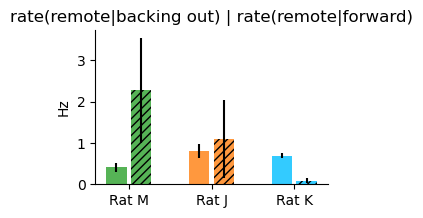

In [167]:
animal_ind = 0
animals = ["molly", "julio", "klein"]
draw_text = False
fig, ax = plt.subplots(1, 1, figsize=(3, 2))#sharey = True)

for animal in animals:
    data2 = np.array(forward_rate[animal])
    data1 = np.array(backing_rate[animal])
    plot_one_axis(data1, data2, animal_ind, ax, animal, draw_annotation = False, draw_text = False)

    animal_ind += 1

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
        
ax.set_xticks(np.arange(len(animals)) + .15);
ax.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
ax.set_title("rate(remote|backing out) | rate(remote|forward)")
ax.set_ylabel("Hz")

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure4/traveling_direction_neural_conditional"
plt.savefig(file_path + ".pdf",bbox_inches='tight')
plt.savefig(file_path + ".png")

In [ ]:
## test start

In [28]:
from spyglass.shijiegu.Analysis_SGU import ChangeofMindRemoteTheta

In [29]:
from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_session_spyglass

In [15]:
nwb_copy_file_name = "eliot20221021_.nwb"
session_name = "04_Seq2Session2"

In [16]:
# load triggered position data

loaded_data = load_triggered_position_decode_session_spyglass(nwb_copy_file_name, int(session_name[:2]),
                                                               "params_both_max_segment_run_time_2_state", 0.1)

[2026-05-10 13:23:33,314][WARNING]: Skipped checksum for file with hash: e3de26a2-75c5-c8b7-941e-21221371b4d0, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_QVWGMRXZ5X.nwb


In [18]:
loaded_data.keys()

dict_keys(['triggered_positions_baseoff', 'triggered_decodes_baseoff', 'triggered_positions', 'triggered_trial_info'])

In [22]:
loaded_data['triggered_trial_info']

[array([29,  1]),
 array([29,  1]),
 array([33,  2]),
 array([38,  2]),
 array([38,  4]),
 array([39,  3]),
 array([47,  1]),
 array([47,  3]),
 array([53,  3]),
 array([53,  3]),
 array([53,  3]),
 array([68,  4]),
 array([72,  3]),
 array([78,  2]),
 array([78,  3]),
 array([78,  2])]

In [ ]:
## test end

In [13]:
angles_animals = {}

theta_params = "params_both_max_run_time_2_state"
classifier_param_name = None

# for animal in ["molly","julio","klein"]:
#     list_of_days = list_of_days_animals[animal]
#     encoding_set = encoding_set_animals[animal]
#     classifier_param_name = classifier_param_name_animals[animal]
#     proportion = 0.1
    
#     (angles_animals[animal], v1, v2,
#      max_posterior_2d, head_orientation, animal_location,
#      parsed_info, parsed_arm) = find_angle_animal(
#                         animal, list_of_days, list_of_days,
#                         theta_params,
#                         encoding_set,
#                         classifier_param_name, proportion,
#                         debug = False, use_gyro = True, imu_param_name = "big_acc_bias")

Loading from spyglass database instead of pickle file.
molly20220416_.nwb
No triggered decode found for  {'nwb_file_name': 'molly20220416_.nwb', 'epoch': 2, 'minimum_duration': 0.02, 'remote_parameter': 'dur_0.02_sum_0.2', 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
No triggered decode found for  {'nwb_file_name': 'molly20220416_.nwb', 'epoch': 4, 'minimum_duration': 0.02, 'remote_parameter': 'dur_0.02_sum_0.2', 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
No triggered decode found for  {'nwb_file_name': 'molly20220416_.nwb', 'epoch': 6, 'minimum_duration': 0.02, 'remote_parameter': 'dur_0.02_sum_0.2', 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
No triggered decode found for  {'nwb_file_name': 'molly20220416_.nwb', 'epoch': 10, 'minimum_duration': 0.02, 'remote_parameter': 'dur_0.02_sum_0.2', 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
molly20220417_.nwb
molly20220418_.nwb
molly20220419_.nwb


In [14]:
output_path = f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/angle.pkl'
#file_path = 'angle.pkl' # Common extensions are .pkl or .pickle

with open(output_path, 'wb') as file:
    pickle.dump(angles_animals, file)

In [15]:
#angles_animals[animal]

In [16]:
ExportSelection().stop_export(**paper_key, analysis_id="ephys_head_direction_b")

### Plotting

In [17]:
from scipy.stats import binomtest
import starbars
color_by_rat = {"eliot": "C0","molly":"C2","lewis":"C4","julio":"C1","klein":"deepskyblue"}

def sd_err(p,N):
    return np.sqrt(p*(1-p)/N)

def plot_one_axis(p, N, animal_ind, ax, animal, draw_annotation = True, draw_text = False):
    q = 1 - p
    std = [sd_err(p,N), sd_err(q,N)]
    mean = [p, q]
    ax.bar([0 + animal_ind,
                0.3 + animal_ind],mean, yerr=std, width=0.25, hatch=['', '////'],color = color_by_rat[animal], alpha=0.8)
    if draw_text:
        ax.text(animal_ind - 0.15, mean[0]+std[0] + 0.1, len(data1), fontsize = 6)
        ax.text(animal_ind + 0.3 - 0.15, mean[1]+std[1] + 0.1, len(data2), fontsize = 6)

    pN = int(p*N)
    res = binomtest(pN, N, 0.5, alternative = "less")
    p_value = res.pvalue
    print("p_value",p_value)
    if p_value < 0.05 and draw_annotation:
        starbars.draw_annotation([(animal_ind, animal_ind + 0.3, np.round(p_value, 4))], ax = ax)
    return ax, p_value

### Raw angle

In [18]:
VISUAL_FIELD = 110
VISUAL_FIELD_RAD = VISUAL_FIELD/180 * np.pi

In [19]:
output_path = f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/angle.pkl'

with open(output_path, 'rb') as file:
    loaded_data = pickle.load(file)

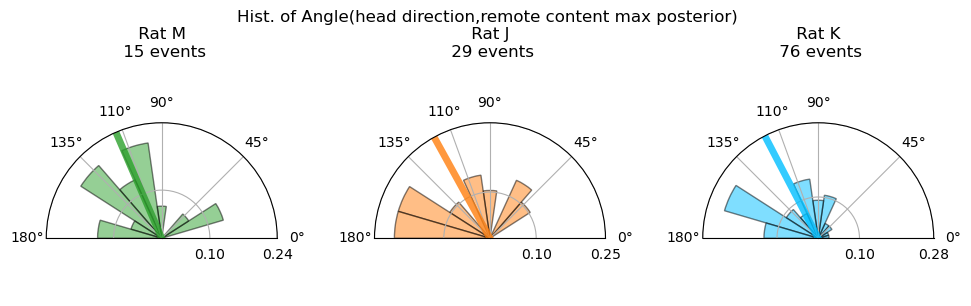

In [20]:
# Create a figure and a polar subplot
fig, axes = plt.subplots(1,3, figsize = (12,3),
                         subplot_kw={'projection': 'polar'})

ind = 0
for animal in ["molly","julio","klein"]:
    angles = loaded_data[animal]
    n, bins, patches = axes[ind].hist(angles, weights = np.ones(len(angles))/len(angles),
                                      bins=np.linspace(0,np.pi,12), alpha=0.5,
                                      color=color_by_rat[animal], edgecolor='black')
    axes[ind].axvline(np.mean(angles), color = color_by_rat[animal], linewidth = 5,
                      alpha = 0.8)
    # axes[ind].plot(VISUAL_FIELD_RAD, color = 'k', linewidth = 3, linestyle = ":",
    #                   alpha = 0.5)

    # Set the title
    if ind == 1:
        axes[ind].set_title(f'Hist. of Angle(head direction,remote content max posterior) \n Rat {animal[0].upper()} \n {len(angles)} events')
    else:
        axes[ind].set_title(f'\n Rat {animal[0].upper()} \n {len(angles)} events')
    axes[ind].set_thetamin(0)
    axes[ind].set_thetamax(180)
    ymin, ymax = axes[ind].get_ylim()
    ymax = np.round(ymax+0.03,2)
    axes[ind].set_rticks([0.1, ymax]) #
    axes[ind].set_ylim([ymin, ymax])
    axes[ind].set_thetagrids([0, 45, 90, 135, VISUAL_FIELD, 180])
    
    ind += 1

#plt.show()

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure4/content_angle"
plt.savefig(file_path + ".pdf",bbox_inches='tight')
plt.savefig(file_path + ".png") 

### Within field vs out-of-field

In [22]:
#fig, ax = plt.subplots(1,1, figsize = (4,3))

ind = 0
for animal in ["molly","julio","klein"]:
    angles = loaded_data[animal]
    N = len(angles)
    in_field = np.sum(np.array(angles) < VISUAL_FIELD_RAD)/N
    out_field = np.sum(np.array(angles) > VISUAL_FIELD_RAD)/N
    print(animal, "out_field",out_field)
    ind += 1

    #plot_one_axis(in_field, N, ind, ax, animal, draw_annotation = True, draw_text = False)

molly out_field 0.6666666666666666
julio out_field 0.5517241379310345
klein out_field 0.5394736842105263
